# Modul 12 - Pengolahan Citra
## Praktikum Teknik Biomedis 4
### Laboratorium IBES - Universitas Telkom

## Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## 🔍 BAGIAN 1: ANALISIS WARNA DENGAN HISTOGRAM

### Gray scale

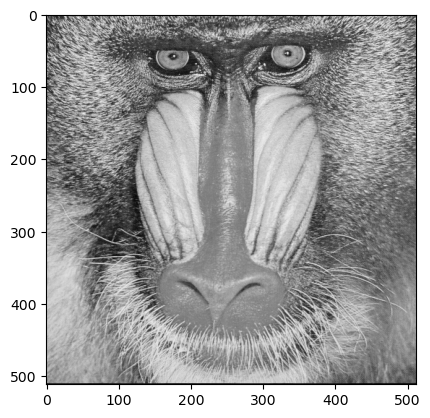

In [2]:
img = cv.imread('baboon.png', cv.IMREAD_GRAYSCALE) 
plt.imshow(img,cmap='gray')
plt.show()

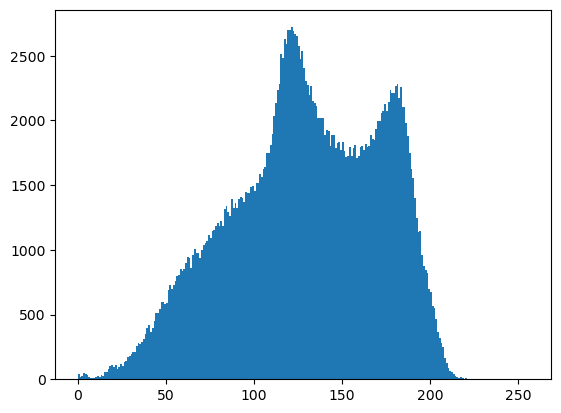

In [3]:
assert img is not None, "file could not be read, check with os.path.exists()"
hist = cv.calcHist([img],[0],None,[256],[0,256])

#Menampilkan representasi histogram pada citra
plt.hist(img.ravel(),256,[0,256]); plt.show()

### Color

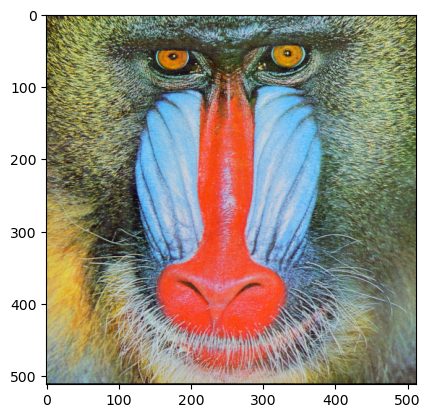

In [4]:
img = cv.imread('baboon.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

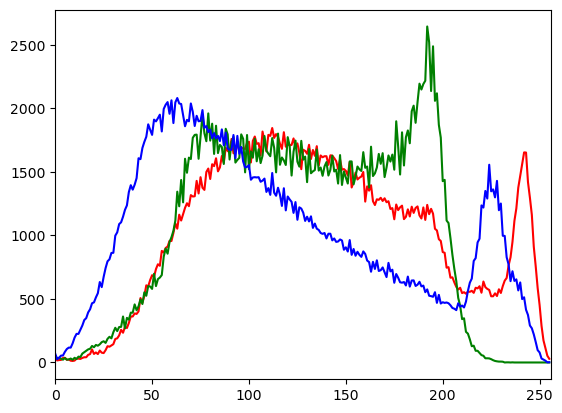

In [5]:
color = ('r','g','b')
for i,col in enumerate(color):
    histr = cv.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()

## 📈 BAGIAN 2: PENINGKATAN KONTRAS DENGAN EKUALISASI HISTOGRAM

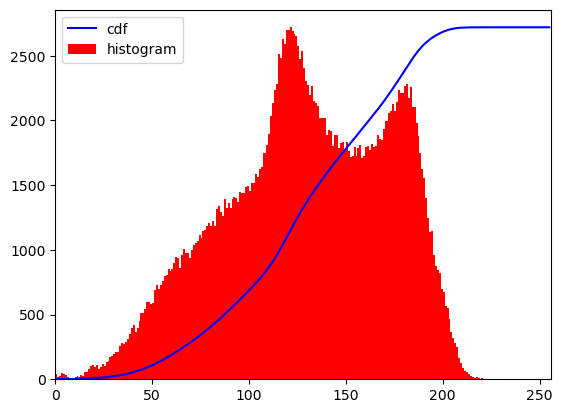

In [6]:
img = cv.imread('baboon.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

hist,bins = np.histogram(img.flatten(),256,[0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.plot(cdf_normalized, color = 'b')
plt.hist(img.flatten(),256,[0,256], color = 'r')
plt.xlim([0,256])
plt.legend(('cdf','histogram'), loc = 'upper left')
plt.show()

### Melakukan ekualisasi histogram dengan manual

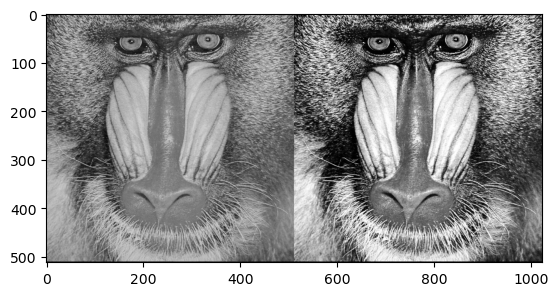

In [7]:
cdf_m = np.ma.masked_equal(cdf,0)
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
cdf = np.ma.filled(cdf_m,0).astype('uint8')
img2 = cdf[img]

res = np.hstack((img,img2)) #stacking images side-by-side
plt.imshow(res, cmap='gray')
plt.show()

### Melakukan ekualisasi histogram dengan paket dari OpenCV

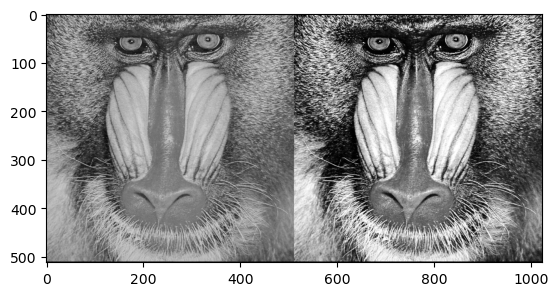

In [8]:
img = cv.imread('baboon.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

equ = cv.equalizeHist(img)
res = np.hstack((img,equ)) #stacking images side-by-side
plt.imshow(res, cmap='gray')
plt.show()

### Melakukan peningkatan kontras dengan CLAHE

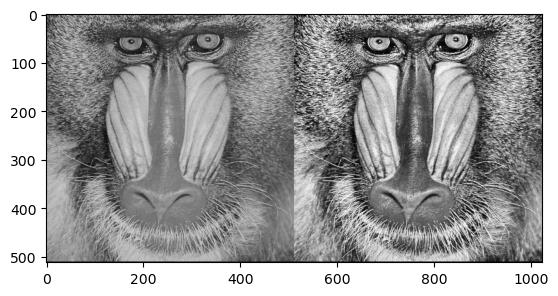

In [9]:
img = cv.imread('baboon.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)

res = np.hstack((img, cl1)) #stacking images side-by-side
plt.imshow(res, cmap='gray')
plt.show()

## 🎨 BAGIAN 3: HISTOGRAM WARNA 2D

### Pembuatan histogram warna dengan OpenCV

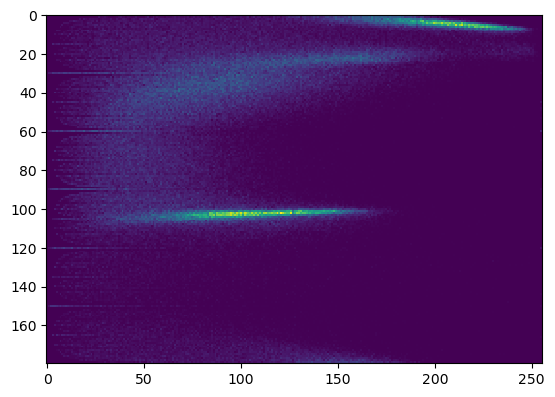

In [10]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

img = cv.imread('baboon.png')
assert img is not None, "file could not be read, check with os.path.exists()"

hsv = cv.cvtColor(img,cv.COLOR_BGR2HSV)
hist = cv.calcHist( [hsv], [0, 1], None, [180, 256], [0, 180, 0, 256] )

plt.imshow(hist,interpolation = 'nearest')
plt.show()

## 🌊 BAGIAN 4: TRANSFORMASI FOURIER

### Magnitude Spectrum

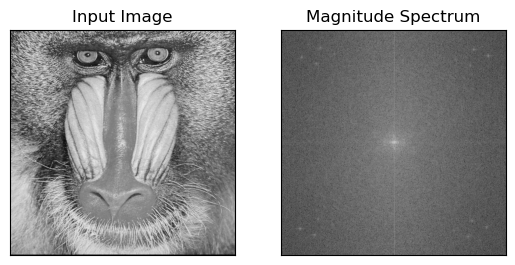

In [11]:
img = cv.imread('baboon.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

dft = cv.dft(np.float32(img),flags = cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

magnitude_spectrum = 20*np.log(cv.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

### Menerapkan low pass filter, untuk memberikan efek blur

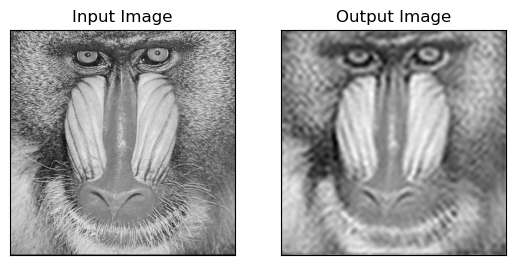

In [12]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2

# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols,2),np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv.idft(f_ishift)
img_back = cv.magnitude(img_back[:,:,0],img_back[:,:,1])

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Output Image'), plt.xticks([]), plt.yticks([])
plt.show()

## ✂️ BAGIAN 5: DETEKSI TEPI

### Deteksi Tepi dengan Sobel

In [13]:
# Read the original image
img = cv.imread('baboon.png') 

# Convert to graycsale
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Blur the image for better edge detection
img_blur = cv.GaussianBlur(img_gray, (3,3), 0) 

# Sobel Edge Detection
sobelx = cv.Sobel(src=img_blur, ddepth=cv.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis
sobely = cv.Sobel(src=img_blur, ddepth=cv.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis
sobelxy = cv.Sobel(src=img_blur, ddepth=cv.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection

### Sobel X

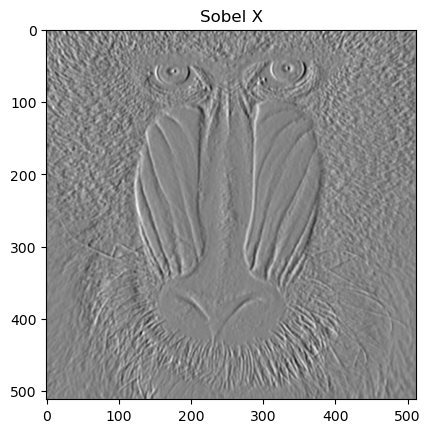

In [14]:
plt.imshow(sobelx, cmap = 'gray')
plt.title('Sobel X')
plt.show()

### Sobel Y

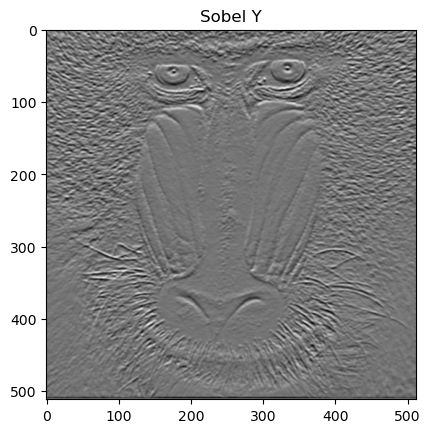

In [15]:
plt.imshow(sobely, cmap = 'gray')
plt.title('Sobel Y')
plt.show()

### Sobel XY

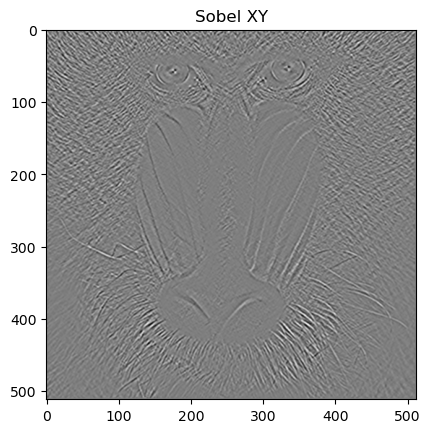

In [16]:
plt.imshow(sobelxy, cmap = 'gray')
plt.title('Sobel XY')
plt.show()

### Deteksi Tepi dengan Canny

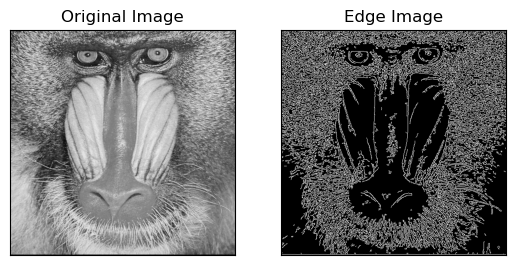

In [17]:
img = cv.imread('baboon.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "file could not be read, check with os.path.exists()"

edges = cv.Canny(img,100,200)

plt.subplot(121),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(edges,cmap = 'gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

---
# SOAL ANALISIS

## Soal 1: Analisis Histogram
**Pertanyaan:** Bandingkan histogram citra grayscale dengan histogram citra berwarna. Apa perbedaan informasi yang dapat diperoleh dari kedua jenis histogram tersebut?

**Jawaban:**


**Histogram Grayscale:**
- Menampilkan distribusi intensitas piksel dalam satu dimensi (0-255)
- Memberikan informasi tentang kecerahan/brightness dan kontras citra
- Lebih sederhana untuk dianalisis
- Cocok untuk analisis tekstur dan pola struktur

**Histogram Citra Berwarna:**
- Menampilkan distribusi untuk tiga kanal warna (R, G, B)
- Memberikan informasi lebih detail tentang komposisi warna
- Dapat mengidentifikasi dominasi warna tertentu dalam citra
- Lebih kompleks tetapi memberikan informasi yang lebih kaya

**Perbedaan Informasi:**
- Histogram grayscale fokus pada luminance/intensitas
- Histogram warna memberikan informasi chrominance (warna)
- Histogram warna dapat mendeteksi perbedaan objek berdasarkan warna meskipun intensitas sama
- Dalam aplikasi medis, histogram grayscale sering digunakan untuk X-ray, sedangkan histogram warna untuk analisis jaringan mikroskopis

## Soal 2: Ekualisasi Histogram
**Pertanyaan:** Jelaskan perbedaan hasil antara ekualisasi histogram manual dengan menggunakan fungsi `cv.equalizeHist()` dari OpenCV. Manakah yang lebih efektif dan mengapa?

**Jawaban:**

**Ekualisasi Manual:**
- Menggunakan CDF (Cumulative Distribution Function) yang dihitung sendiri
- Melibatkan langkah: menghitung histogram → CDF → normalisasi → mapping
- Memberikan kontrol penuh atas proses
- Lebih lambat secara komputasi
- Memungkinkan modifikasi algoritma sesuai kebutuhan

**Fungsi `cv.equalizeHist()`:**
- Implementasi yang sudah dioptimasi oleh OpenCV
- Menggunakan algoritma standar yang telah terbukti
- Lebih cepat dan efisien
- Mudah digunakan (satu baris kode)
- Hasil konsisten dan stabil

**Yang Lebih Efektif:**
- **Untuk praktik umum**: `cv.equalizeHist()` lebih efektif karena kecepatan eksekusi lebih tinggi, implementasi yang sudah dioptimasi, lebih sedikit kemungkinan error
- **Untuk penelitian/custom**: Manual lebih fleksibel untuk modifikasi algoritma
- **Aplikasi Biomedis**: Dalam citra medis seperti X-ray atau MRI, `cv.equalizeHist()` lebih direkomendasikan untuk konsistensi diagnosis

## Soal 3: CLAHE vs Histogram Equalization
**Pertanyaan:** Apa keunggulan menggunakan CLAHE (Contrast Limited Adaptive Histogram Equalization) dibandingkan dengan ekualisasi histogram biasa? Berikan contoh kasus di mana CLAHE lebih cocok digunakan.

**Jawaban:**

1. **Adaptive/Lokal:**
   - Membagi citra menjadi tile-tile kecil (default 8x8)
   - Ekualisasi dilakukan per tile, bukan global
   - Mempertahankan detail lokal yang hilang pada ekualisasi global

2. **Contrast Limiting:**
   - Parameter `clipLimit` mencegah over-amplification noise
   - Mengurangi artefak yang tidak diinginkan
   - Hasil lebih natural dan tidak berlebihan

3. **Interpolasi:**
   - Menggunakan bilinear interpolation antar tile
   - Menghindari boundary artifacts
   - Transisi yang lebih halus

**Contoh Kasus Cocok untuk CLAHE:**
1. **Citra Medis:** X-ray dada (detail tulang rusuk dan jaringan paru), CT Scan (kontras antara organ berbeda), Mammografi (deteksi massa kecil pada jaringan payudara)
2. **Citra dengan Pencahayaan Tidak Merata:** Mikroskopi dengan illumination gradient, citra satelit dengan bayangan
3. **Citra dengan Range Intensitas Luas:** MRI dengan kontras jaringan yang bervariasi

## Soal 4: Transformasi Fourier
**Pertanyaan:** Dari hasil transformasi Fourier yang telah dilakukan, apa informasi yang dapat diperoleh dari magnitude spectrum? Mengapa pusat spektrum lebih terang dibandingkan bagian tepi?

**Jawaban:**

**Informasi dari Magnitude Spectrum:**
1. **Komponen Frekuensi:** Menunjukkan distribusi frekuensi spasial dalam citra (frekuensi rendah = variasi intensitas lambat, frekuensi tinggi = variasi intensitas cepat/edges/noise)
2. **Karakteristik Citra:** Energi dominan pada frekuensi tertentu, pola periodicitas, orientasi struktur dominan
3. **Aplikasi:** Filtering, deteksi pola berulang, analisis tekstur, kompresi citra

**Mengapa Pusat Lebih Terang:**
1. **DC Component (0,0):** Frekuensi nol = nilai rata-rata citra, biasanya memiliki magnitude terbesar, muncul sebagai titik paling terang di pusat
2. **Distribusi Alami:** Kebanyakan citra natural memiliki energi terbesar pada frekuensi rendah, frekuensi rendah terkonsentrasi di pusat spektrum
3. **Sifat Transformasi:** FFT shift menempatkan frekuensi rendah di pusat, intensitas logaritmik (20*log) memperjelas perbedaan

**Aplikasi Biomedis:** Filtering noise pada citra X-ray, analisis tekstur jaringan pada histopatologi, deteksi pola pada citra mikroskopi

## Soal 5: Perbandingan Deteksi Tepi
**Pertanyaan:** Bandingkan hasil deteksi tepi menggunakan operator Sobel (X, Y, XY) dengan algoritma Canny. Apa kelebihan dan kekurangan masing-masing metode?

**Jawaban:**

**Operator Sobel:**
- **Sobel X**: Mendeteksi tepi vertikal (perubahan horizontal)
- **Sobel Y**: Mendeteksi tepi horizontal (perubahan vertikal)  
- **Sobel XY**: Kombinasi deteksi tepi di kedua arah

**Kelebihan Sobel:** Sederhana dan cepat, dapat memilih arah deteksi spesifik, memberikan informasi magnitude dan direction, robust terhadap noise

**Kekurangan Sobel:** Tepi yang dihasilkan tebal, tidak optimal untuk tepi yang tipis, tidak ada supresi non-maksimum

**Algoritma Canny:**
- **Tahapan**: Gaussian smoothing → Gradient computation → Non-maximum suppression → Double thresholding → Edge tracking by hysteresis

**Kelebihan Canny:** Tepi tipis dan presisi, non-maximum suppression menghasilkan tepi single-pixel, double threshold mengurangi false edges, optimal edge detector

**Kekurangan Canny:** Lebih kompleks dan lambat, membutuhkan tuning parameter, sensitif terhadap noise

**Aplikasi Biomedis:**
- **Sobel cocok untuk**: Deteksi orientasi struktur (tulang pada X-ray), analisis tekstur directional
- **Canny cocok untuk**: Segmentasi presisi (boundary organ), deteksi kontur sel, analisis morfologi yang membutuhkan akurasi tinggi

## Soal 6: Aplikasi dalam Bidang Biomedis
**Pertanyaan:** Sebutkan dan jelaskan 3 aplikasi teknik pengolahan citra yang telah dipelajari dalam modul ini untuk bidang teknik biomedis. Berikan contoh konkret untuk masing-masing aplikasi.

**Jawaban:**

**1. Histogram Equalization untuk Enhancement Citra Medis:**
- **Aplikasi**: Peningkatan kontras pada citra medis dengan dynamic range rendah
- **Contoh**: X-ray Dada (kontras tulang-jaringan lunak-udara paru), CT Scan Kepala (gray matter vs white matter), Mammografi (visibilitas massa kecil/mikrokalsifikasi)
- **Manfaat**: Membantu radiolog mendeteksi abnormalitas, meningkatkan akurasi diagnosis

**2. CLAHE untuk Adaptive Enhancement:**
- **Aplikasi**: Enhancement lokal pada citra dengan pencahayaan tidak merata
- **Contoh**: Fundus Photography (deteksi diabetic retinopathy), Mikroskopi Histopatologi (struktur sel dan jaringan), Ultrasound Imaging (kontras organ dengan acoustic shadowing)
- **Manfaat**: Mengurangi artefak over-enhancement, mempertahankan informasi diagnostik

**3. Edge Detection untuk Segmentasi dan Analisis Morfologi:**
- **Aplikasi**: Segmentasi organ dan struktur anatomis, analisis bentuk dan ukuran abnormalitas
- **Contoh Sobel**: X-ray Tulang (deteksi fraktur), Citra Mikroskopi (analisis orientasi serat kolagen)
- **Contoh Canny**: MRI Brain (segmentasi tumor), Echocardiography (boundary jantung untuk ejection fraction), Histopatologi (segmentasi sel kanker)
- **Manfaat**: Otomatisasi pengukuran klinis, objektifitas assessment, computer-aided diagnosis

**Aplikasi Tambahan:**
- **Fourier Transform**: Low-pass filtering (reduksi noise X-ray), High-pass filtering (sharpening MRI)
- **Color Histogram**: Immunohistochemistry (quantifikasi protein expression), wound healing monitoring, skin lesion analysis

---